# 02 — Baseline: EWOA + KNN (Supervised)

**Cel:** Odtwarzamy klasyczny baseline z artykułu: **Enhanced Whale Optimization Algorithm (EWOA)** do selekcji cech oraz **K-Nearest Neighbors (KNN)** do klasyfikacji.

To jest punkt odniesienia dla modeli AE/VAE: zamiast uczyć reprezentacji siecią, najpierw wybieramy podzbiór najlepszych cech, a potem klasyfikujemy próbki na podstawie najbliższych sąsiadów.

### Plan notebooka:
1. Wczytaj dane i zrób split train/val/test
2. Uruchom EWOA do wyboru najlepszego podzbioru cech
3. Naucz finalny model KNN na wybranych cechach
4. Oceń metryki na zbiorze testowym
5. Zapisz wyniki, listę cech i macierz pomyłek

In [1]:
import json
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path("..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.baselines import EWOAKNNConfig, run_ewoa_knn_pipeline
from src.data.loader import load_raw_data, make_sklearn_splits, prepare_features_and_labels
from src.utils.config import CLASS_NAMES, RESULTS_METRICS_DIR, RESULTS_PLOTS_DIR, SEED

np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
print("Importy OK")

Importy OK


## 1. Wczytanie danych

Używamy trybu `multiclass` — 4 klasy: Benign, Spyware, Ransomware, Trojan.

Najpierw wyciągamy surowe cechy i etykiety, a dopiero potem wykonujemy split oraz skalowanie Min-Max tylko na zbiorze treningowym, żeby uniknąć leakage.

In [2]:
df = load_raw_data("../data/raw")
X, y, feature_names = prepare_features_and_labels(df, mode="multiclass")

X_train, X_val, X_test, y_train, y_val, y_test, scaler = make_sklearn_splits(
    X, y,
    test_size=0.20,
    val_size=0.10,
    scale=True,
    )

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Liczba cech wejściowych: {len(feature_names)}")

for split_name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"\nRozkład klas w {split_name}:")
    counts = pd.Series(labels).value_counts().sort_index()
    for class_idx, count in counts.items():
        print(f"  {CLASS_NAMES[class_idx]}: {count}")

Wczytano 58058 wierszy z 1 pliku/plików.
Kolumny (57): ['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit'] ...
  58058 próbek | 55 cech | tryb: multiclass
  Rozkład klas: {'Benign': 29227, 'Spyware': 9815, 'Ransomware': 9529, 'Trojan': 9487}
Train: (40640, 55) | Val: (5806, 55) | Test: (11612, 55)
Liczba cech wejściowych: 55

Rozkład klas w train:
  Benign: 20458
  Spyware: 6871
  Ransomware: 6670
  Trojan: 6641

Rozkład klas w val:
  Benign: 2923
  Spyware: 981
  Ransomware: 953
  Trojan: 949

Rozkład klas w test:
  Benign: 5846
  Spyware: 1963
  Ransomware: 1906
  Trojan: 1897


## 2. Algorytm baseline

**EWOA** przeszukuje przestrzeń możliwych podzbiorów cech i szuka takiego zestawu, który daje najlepszy wynik walidacyjny przy możliwie małej liczbie cech.

**KNN** nie uczy wag jak sieć neuronowa. Przy predykcji patrzy na `k` najbliższych próbek treningowych i głosuje ich klasami.

In [3]:
config = EWOAKNNConfig(
    n_whales=18,
    n_iterations=25,
    min_features=4,
    penalty_weight=0.015,
    k_neighbors=5,
    weights="distance",
    metric="minkowski",
    p=2,
    scoring="accuracy",
    random_state=SEED,
)

config

EWOAKNNConfig(n_whales=18, n_iterations=25, min_features=4, penalty_weight=0.015, k_neighbors=5, weights='distance', metric='minkowski', p=2, scoring='accuracy', spiral_constant=1.0, random_state=42)

## 3. Selekcja cech EWOA i trening KNN

Tutaj nie ma backpropagation ani epok. Zamiast tego EWOA iteracyjnie poprawia maskę cech, a jako funkcję jakości wykorzystujemy skuteczność KNN na zbiorze walidacyjnym.

Po zakończeniu optymalizacji finalny KNN jest uczony na `train + val` tylko na wybranych cechach i oceniany na teście.

In [4]:
results = run_ewoa_knn_pipeline(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    feature_names=feature_names,
    class_names=CLASS_NAMES,
    config=config,
)

selection = results["selection"]
metrics = results["metrics"]
history_df = pd.DataFrame(results["history"])
cm = results["confusion_matrix"]
y_pred = np.array(results["y_pred"])

print(f"Najlepszy wynik walidacyjny ({config.scoring}): {selection['best_score']:.4f}")
print(f"Liczba wybranych cech: {len(selection['selected_feature_names'])} / {len(feature_names)}")
print("\nWybrane cechy:")
for idx, name in enumerate(selection["selected_feature_names"], start=1):
    print(f"  {idx:2d}. {name}")

Najlepszy wynik walidacyjny (accuracy): 0.8639
Liczba wybranych cech: 13 / 55

Wybrane cechy:
   1. pslist.nproc
   2. dlllist.avg_dlls_per_proc
   3. handles.nkey
   4. handles.nsemaphore
   5. handles.ntimer
   6. ldrmodules.not_in_load
   7. ldrmodules.not_in_mem
   8. ldrmodules.not_in_load_avg
   9. malfind.uniqueInjections
  10. psxview.not_in_eprocess_pool_false_avg
  11. svcscan.kernel_drivers
  12. svcscan.process_services
  13. svcscan.nactive


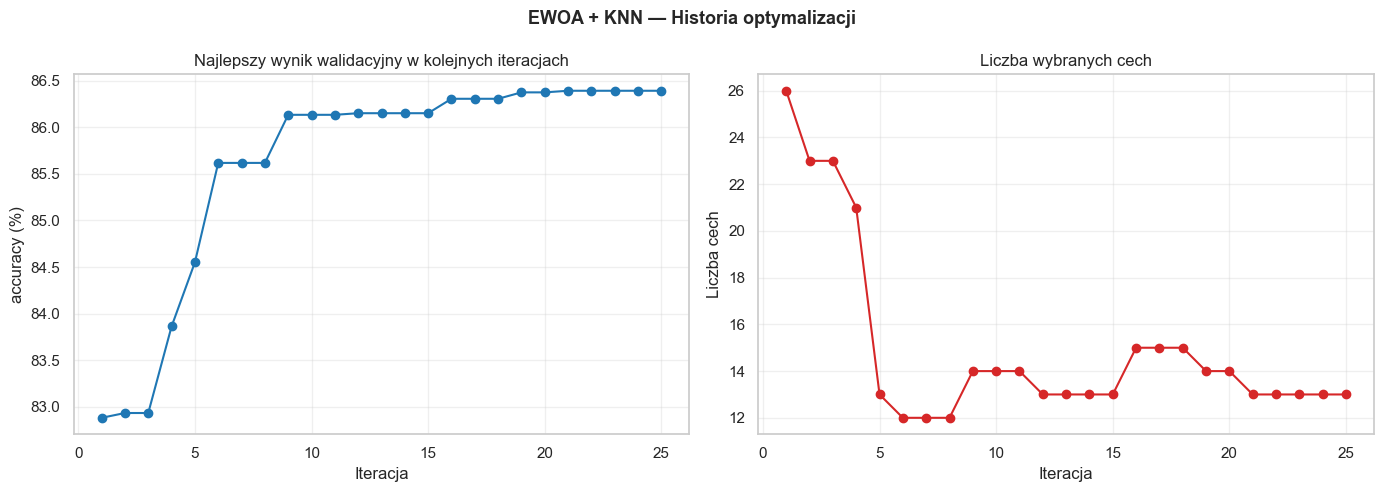

Końcowy test accuracy: 86.01%


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_df["iteration"], history_df["best_score"] * 100, marker="o", color="#1f77b4")
ax1.set_title("Najlepszy wynik walidacyjny w kolejnych iteracjach")
ax1.set_xlabel("Iteracja")
ax1.set_ylabel(f"{config.scoring} (%)")
ax1.grid(True, alpha=0.3)

ax2.plot(history_df["iteration"], history_df["selected_features"], marker="o", color="#d62728")
ax2.set_title("Liczba wybranych cech")
ax2.set_xlabel("Iteracja")
ax2.set_ylabel("Liczba cech")
ax2.grid(True, alpha=0.3)

plt.suptitle("EWOA + KNN — Historia optymalizacji", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/plots/05_ewoa_knn_history.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Końcowy test accuracy: {metrics['accuracy']:.2f}%")

## 4. Ewaluacja na zbiorze testowym

Zbiór testowy nie bierze udziału ani w selekcji cech, ani w doborze sąsiadów. Dzięki temu końcowy wynik jest uczciwą oceną całego pipeline'u EWOA + KNN.

In [6]:
print(f"=== Test Accuracy: {metrics['accuracy']:.3f}% ===\n")
print(results["classification_report"])

print("Metryki zbiorcze:")
for metric_name in [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "auc_ovr_macro",
]:
    value = metrics[metric_name]
    suffix = "%" if metric_name != "auc_ovr_macro" else ""
    print(f"  {metric_name}: {value:.4f}{suffix}")

=== Test Accuracy: 86.006% ===

              precision    recall  f1-score   support

      Benign     0.9997    1.0000    0.9998      5846
     Spyware     0.7445    0.7988    0.7707      1963
  Ransomware     0.6878    0.6842    0.6860      1906
      Trojan     0.7202    0.6690    0.6936      1897

    accuracy                         0.8601     11612
   macro avg     0.7880    0.7880    0.7875     11612
weighted avg     0.8597    0.8601    0.8596     11612

Metryki zbiorcze:
  accuracy: 86.0059%
  precision_macro: 78.8041%
  recall_macro: 78.7971%
  f1_macro: 78.7530%
  precision_weighted: 85.9683%
  recall_weighted: 86.0059%
  f1_weighted: 85.9554%
  auc_ovr_macro: 0.9391


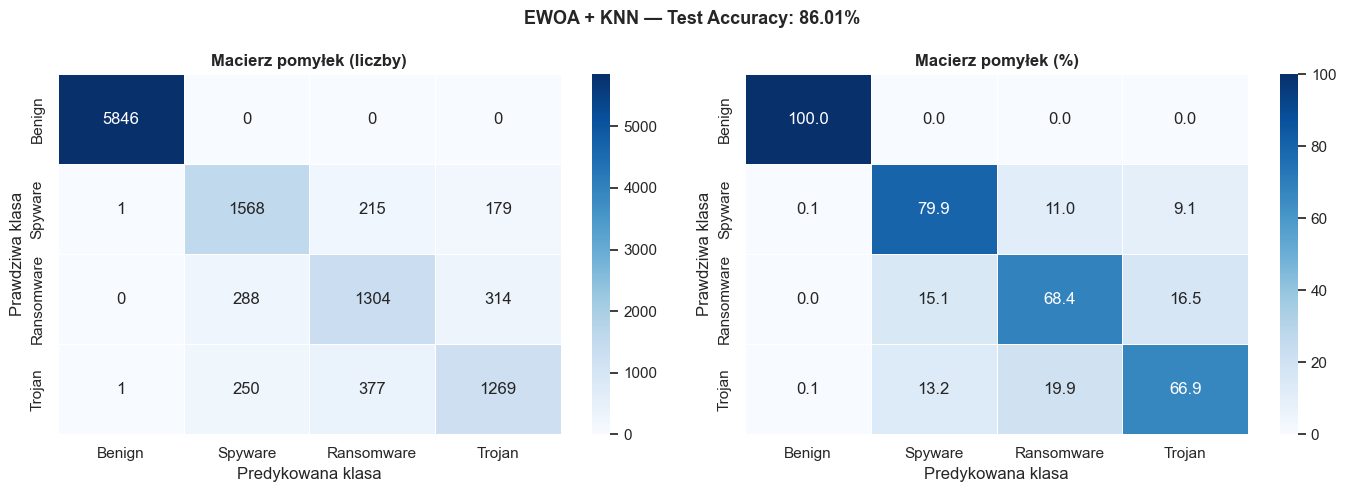

In [7]:
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0],
    linewidths=0.5,
    )
axes[0].set_title("Macierz pomyłek (liczby)", fontweight="bold")
axes[0].set_ylabel("Prawdziwa klasa")
axes[0].set_xlabel("Predykowana klasa")

sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
    linewidths=0.5, vmin=0, vmax=100,
    )
axes[1].set_title("Macierz pomyłek (%)", fontweight="bold")
axes[1].set_ylabel("Prawdziwa klasa")
axes[1].set_xlabel("Predykowana klasa")

plt.suptitle(f"EWOA + KNN — Test Accuracy: {metrics['accuracy']:.2f}%", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/plots/06_ewoa_knn_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Zapis wyników i porównanie z artykułem

In [8]:
paper_acc = 99.987

results_to_save = {
    "model": "EWOA + KNN (supervised)",
    "selection_metric": config.scoring,
    "n_whales": config.n_whales,
    "n_iterations": config.n_iterations,
    "k_neighbors": config.k_neighbors,
    "selected_feature_count": len(selection["selected_feature_names"]),
    "selected_features": selection["selected_feature_names"],
    "best_validation_score": round(selection["best_score"] * 100, 4),
    "accuracy": round(metrics["accuracy"], 4),
    "precision_macro": round(metrics["precision_macro"], 4),
    "recall_macro": round(metrics["recall_macro"], 4),
    "f1_macro": round(metrics["f1_macro"], 4),
    "precision_weighted": round(metrics["precision_weighted"], 4),
    "recall_weighted": round(metrics["recall_weighted"], 4),
    "f1_weighted": round(metrics["f1_weighted"], 4),
    "auc_ovr_macro": round(metrics["auc_ovr_macro"], 6),
}

metrics_path = pathlib.Path(RESULTS_METRICS_DIR) / "ewoa_knn_results.json"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics_path.write_text(json.dumps(results_to_save, indent=2), encoding="utf-8")
print(f"Zapisano: {metrics_path}")

print()
print("=" * 60)
print("  PORÓWNANIE Z ARTYKUŁEM BAZOWYM")
print("=" * 60)
print(f"  Artykuł (EWOA+KNN): Accuracy = {paper_acc:.3f}%")
print(f"  Nasz EWOA+KNN:      Accuracy = {metrics['accuracy']:.3f}%")
print(f"  Różnica:            {(paper_acc - metrics['accuracy']):+.3f} pp")
print()
print(f"  Wybrane cechy:      {len(selection['selected_feature_names'])}")
print(f"  Validation score:   {selection['best_score'] * 100:.3f}%")
print(f"  F1 macro:           {metrics['f1_macro']:.3f}%")
print(f"  AUC OVR macro:      {metrics['auc_ovr_macro']:.4f}")
print("=" * 60)

print()
print("NASTĘPNY KROK → notebooks/03_autoencoder.ipynb")
print("  Porównanie deep learning vs klasyczny baseline EWOA + KNN")

Zapisano: E:\AGH\Studia magisterskie\8. semestr\Deep Learning and Computational Intelligence\DL-Project\results\metrics\ewoa_knn_results.json

  PORÓWNANIE Z ARTYKUŁEM BAZOWYM
  Artykuł (EWOA+KNN): Accuracy = 99.987%
  Nasz EWOA+KNN:      Accuracy = 86.006%
  Różnica:            +13.981 pp

  Wybrane cechy:      13
  Validation score:   86.393%
  F1 macro:           78.753%
  AUC OVR macro:      0.9391

NASTĘPNY KROK → notebooks/03_autoencoder.ipynb
  Porównanie deep learning vs klasyczny baseline EWOA + KNN
